## Context

I've recently stumbled upon an English vocabulary which can be found here https://github.com/dwyl/english-words, which [I've also uploaded into Kaggle](https://www.kaggle.com/datasets/bwandowando/479k-english-words). I also came up with a way to utilize this new dataset along with the [Meta-Kaggle dataset](https://www.kaggle.com/datasets/kaggle/meta-kaggle/). This notebook will attempt to identify the users that have the broadest vocabulary by counting the tokens used per user, that are in the English vocabulary dataset.


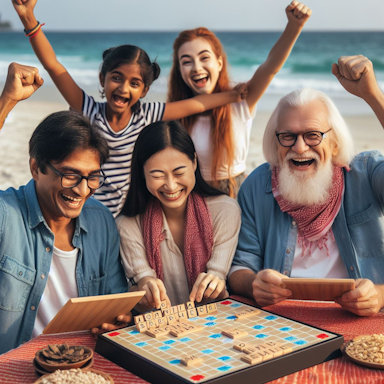

*Yes, the old man has three arms.*

## Limitations
This notebook has some limitations, but for transparency, here they are

This notebook...

1. Doesn't expand contractions ex: `can't to can not`, and `won't to will not`.
2. Doesn't replace acronyms and abbreviations, ex: `Doesnt convert GPT to Generative Pre-training Transformer`
3. Doesn't correct misspelled words.
4. Can't distinguish copied text from articles and online tools versus human inputted text.
5. (Only) counts tokens that have no symbols and numbers are counted.
6. Doesn't analyze proper grammar and usage(s) of words.
7. Uses ForumMessages and ForumTopics data only

## Main libraries used

1. [BeautifulSoup](https://en.wikipedia.org/wiki/Beautiful_Soup_(HTML_parser)- a Python package for parsing HTML and XML documents (including having malformed markup, i.e. non-closed tags, so named after tag soup). It creates a parse tree for parsed pages that can be used to extract data from HTML, which is useful for web scraping
2. [Pandas](https://pandas.pydata.org/)- a fast, powerful, flexible and easy to use open source data analysis and manipulation tool,
built on top of the Python programming language.
3. [Swifter](https://github.com/jmcarpenter2/swifter) - A package which efficiently applies any function to a pandas dataframe or series in the fastest available manner
4. [Counter](https://docs.python.org/3/library/collections.html#collections.Counter)- is a dict subclass for counting hashable objects. It is a collection where elements are stored as dictionary keys and their counts are stored as dictionary values

## Let's install swifter

In [ ]:
!pip3 install swifter -q

## Import the necessary libraries

In [ ]:
from bs4 import BeautifulSoup
from collections import Counter

import datetime
import pandas as  pd
import swifter

## Some readability tweaks to pandas dataframe

In [ ]:
pd.set_option('max_colwidth', 400)

## Let's set our datefilter at January 01, 2023 

You can fork this notebook and change the date filter, though expect longer processing times and higher resource requirements!

In [ ]:
date_filter = datetime.date(month=1,day=1, year=2023)

## Load the meta-kaggle csvs into dataframes

In [ ]:
df_forum_topics = pd.read_csv("/kaggle/input/meta-kaggle/ForumTopics.csv")
df_forum_messages = pd.read_csv("/kaggle/input/meta-kaggle/ForumMessages.csv")
df_users = pd.read_csv("/kaggle/input/meta-kaggle/Users.csv")

## Let's get the list of UserIds

In [ ]:
user_ids = df_users["Id"].tolist()

## Let's load the file where words_alpha.txt for words that only have letters, and no numbers or symbols.

In [ ]:
with open('/kaggle/input/479k-english-words/words_alpha.txt') as word_file:
    valid_words = set(word_file.read().split())
    
valid_words_count = len(valid_words)

## Let's declare what will our top X users with most unique tokens cutoff-value will be, this is also to minimize the data that we will be processing later

In [ ]:
TOP_X_USERS = 100

## Let's cast the creationdate and postdate fields to datetime, then we filter the two dataframes

In [ ]:
df_forum_topics['CreationDate'] = pd.to_datetime(df_forum_topics['CreationDate'])
df_forum_topics = df_forum_topics[df_forum_topics["CreationDate"].dt.date >= date_filter]

In [ ]:
df_forum_messages['PostDate'] = pd.to_datetime(df_forum_messages['PostDate'])
df_forum_messages = df_forum_messages[df_forum_messages["PostDate"].dt.date >= date_filter]

## Let's join the topic dataframe with the forum message to get the PostUserId field

In [ ]:
df_topics_with_post_user_id =pd.merge(df_forum_topics, df_forum_messages, left_on=["Id","FirstForumMessageId"], right_on=["ForumTopicId","Id"], how="inner")[["PostUserId","Title"]]

## We rename the title field to Message, we will concat both dataframes as one later

In [ ]:
df_topics_with_post_user_id = df_topics_with_post_user_id.rename(columns={"Title":"Message"})

## We concat the two dataframes as one

In [ ]:
df_combined = pd.concat([df_topics_with_post_user_id,df_forum_messages])

## Let's get only those whose UserIds are still existing in the Users dataset

In [ ]:
df_combined = df_combined[df_combined["PostUserId"].isin(user_ids)]

## Let's filter out records that have a null Message field value

In [ ]:
df_combined = df_combined[df_combined["Message"].notnull()][["PostUserId","Message"]]

## Let's run BeautifulSoup against the combine dataframe and remove html tags

In [ ]:
df_combined["MessageNoHtml"] = df_combined["Message"].swifter.apply(lambda x: BeautifulSoup(x, "lxml").text)

## Let's get the token counts and message lengths, we will use this information later

In [ ]:
df_combined["MessagesTokenLength"] = df_combined["MessageNoHtml"].str.split().str.len()
df_combined["MessagesLength"] = df_combined["MessageNoHtml"].str.len()

## Get the postcount here, we define posts as Messages and Titles

In [ ]:
df_agg_user_messages = df_combined.groupby(["PostUserId"]).agg({"Message": ["count"], "MessagesTokenLength":["median"], "MessagesLength":["median"]}).reset_index()
df_agg_user_messages.columns = ['_'.join(col).strip() for col in df_agg_user_messages.columns.values]
df_agg_user_messages = df_agg_user_messages.rename(columns={"PostUserId_":"PostUserId","Message_count":"PostCount","MessagesTokenLength_median":"MedianTokenLength","MessagesLength_median":"MedianMessageLength"})

## Let's create a new field that only contains tokens that are purely alphabet

In [ ]:
df_combined['MessageNoHtmlAlphaNumeric'] = df_combined["MessageNoHtml"].swifter.apply(lambda x: [word.lower() for word in x.split() if word.isalpha()])

## Let's run Counter to all records, then let's join the keys as one string. This acts as first level of deduplication per user, per message

In [ ]:
results = Counter()
df_combined['MessageNoHtmlAlphaNumeric'] = df_combined["MessageNoHtmlAlphaNumeric"].swifter.apply(lambda x: " ".join(list(Counter(x).keys())))

## Let's take a look on the progression of our transformations by looking at five random records

In [ ]:
df_combined.head(5)

## How many records do we have?

In [ ]:
df_combined.shape

## Let's only get the latest "created" field along with the PostUserId

In [ ]:
df_combined = df_combined[['PostUserId','MessageNoHtmlAlphaNumeric']]

## Let's drop duplicates to try and minimize the amount of data that we will be processing later

In [ ]:
df_combined = df_combined[['PostUserId','MessageNoHtmlAlphaNumeric']].drop_duplicates()

## Let's look again on how many records are left

In [ ]:
df_forum_messages.shape

## We now join all the strings as one grouped by the PostUserId field, we will now get a (long) string of the unique tokens that users have posted in the forums

In [ ]:
df_combined['JoinedMessages'] = df_combined[['PostUserId','MessageNoHtmlAlphaNumeric']].groupby(['PostUserId'])['MessageNoHtmlAlphaNumeric'].transform(lambda x: ' '.join(x))

## We drop duplicate records again, and we should now only get records that are unique to a PostUserId

In [ ]:
df_combined = df_combined[['PostUserId','JoinedMessages']].drop_duplicates()

## How many records do we have now?

In [ ]:
df_combined.shape

## We apply a final set to remove the duplicate tokens at a per-user level

In [ ]:
df_combined['JoinedMessages'] = df_combined["JoinedMessages"].str.split().apply(set).str.join(" ")

## Ugh the indexes look ugly and are jagged,  I want to see continuous numbers

In [ ]:
df_combined = df_combined.reset_index(drop=True)

## We split the field and create a list

In [ ]:
df_combined["JoinedMessages"] = df_combined["JoinedMessages"].str.split()

In [ ]:
#df_combined["UniqueTokenCount"] = df_combined["JoinedMessages"].str.len()

## We will use set and intersection to get the tokens that exists both in the master english file and the per-user-distinct-tokens, this is a very fast operation

In [ ]:
df_combined["TokensInEnglishVocabulary"] = df_combined["JoinedMessages"].swifter.apply(lambda x: set(x) & valid_words)

In [ ]:
df_combined["TokensInEnglishVocabularyCount"] = df_combined["TokensInEnglishVocabulary"].str.len()

## Let's Join the Users dataframe that we loaded above to see the names

In [ ]:
df_top_users = pd.merge(df_users[["Id","UserName","DisplayName"]], df_combined, left_on=["Id"], right_on=["PostUserId"])
df_top_users = pd.merge(df_top_users, df_agg_user_messages, left_on=["PostUserId"], right_on=["PostUserId"])

## Let's drop some unwanted fields

In [ ]:
df_top_users = df_top_users.drop(columns=["PostUserId","JoinedMessages"], errors="ignore")

## Let's rename the Id field to make it more intuitive

In [ ]:
df_top_users = df_top_users.rename(columns = {"Id":"UserId"})

## Im now just interested on the TOP_X_USERS that have used the most tokens

In [ ]:
df_top_users = df_top_users.nlargest(TOP_X_USERS, 'TokensInEnglishVocabularyCount').reset_index(drop=True)

## Let's compute for the AverageUniqueTokensPerMessage and TokensInEnglishVocabularyPercent fields

In [ ]:
df_top_users["AverageUniqueTokensPerMessage"] = df_top_users["TokensInEnglishVocabularyCount"] / df_top_users["PostCount"]
df_top_users["TokensInEnglishVocabularyPercent"] = df_top_users["TokensInEnglishVocabularyCount"]/ valid_words_count 
df_top_users["TokensInEnglishVocabularyPercent"] = df_top_users['TokensInEnglishVocabularyPercent'].map(lambda x: '{:,.2%}'.format(x))

## How many unique tokens in the loaded vocabulary data file?

In [ ]:
valid_words_count

## Let's see the top 10 with the widest vocabulary utilization

In [ ]:
df_top_users.head(10)

## Let's see the top 10 users with highest average unique tokens per post

In [ ]:
df_top_users.nlargest(10, 'AverageUniqueTokensPerMessage').reset_index(drop=True)

## About The top most member

Utilizing more than 7ooo unique English tokens, [MPWOLKE](https://www.kaggle.com/mpwolke), she is well decorated in terms of educational attainment and professional achievement(s) thus it's easy to infer that she is well-read and is constantly utilizing and communicating with others using English in a very fluent and intuitive manner

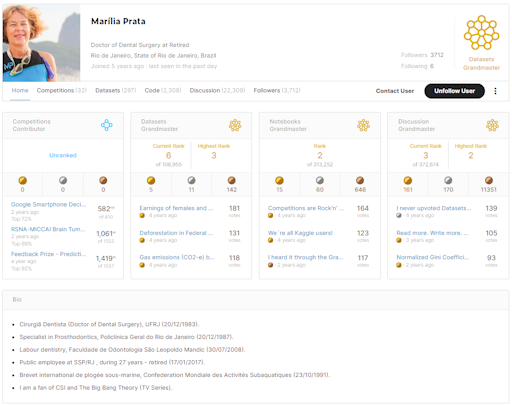

## Summary

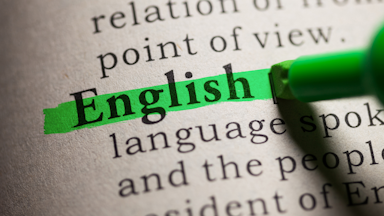

According to this [LinkedIn Post](https://www.linkedin.com/pulse/how-many-words-english-language-955-rule-etoninstitute/)

> The 95/5 rule states that 95% of a language can be learned by mastering the most common 5% of its vocabulary. This principle applies to language learning, and by focusing on the most commonly used words, learners can achieve proficiency faster. Applying [Pareto's principle](https://www.investopedia.com/terms/p/paretoprinciple.asp) in language learning involves identifying and prioritizing high-frequency words.


Another important information that was stated in the article is that there is an estimated 17o,ooo words in the English language that are currently in use, and to achieve a level of basic fluency, knowing to use around 3ooo words is required.

Based on the table above, it's unsurprising to see that the members who have the broadest utilized vocabulary have also posted a lot of threads and messages. We can even dig deeper and see correlations between post counts, number of days as members, number of followers, etc, etc, but my intention is to simply identify the  members have utilized the broadest vocabulary, which we've accomplished. 

## Parting Words

I hope that you've learned a new thing or two today, aside from having fun reading through my notebook. If you did like my notebook, hit the upvote button and it will inspire me to create more of these notebooks that poke into meta-kaggle.

I wish you peaceful skies wherever you are, stay curious and always be awesome!

[BwandoWando](https://www.kaggle.com/BwandoWando)